# Spatial Intermediate Files

Creates regridded, thresholded intermediate files of proxies used for spatial plots

Contributions by Cait Roufa

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import os
from copy import deepcopy
from concurrent.futures import ProcessPoolExecutor
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask

In [2]:
# path setup
geog_path = "/home/scratch/WRF_BCC/geography/geo_em.d01.nc"
output_dir = "/home/scratch/croufa/syn_sev"
os.makedirs(output_dir, exist_ok=True)

epochs = {
    'HIST': '/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*',
    '4p5MID': '/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*',
    '8p5MID': '/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*',
    '4p5END': '/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*',
    '8p5END': '/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*',
}

In [3]:
# load geography
geog = xr.open_dataset(geog_path)

In [4]:
# set coordinates and regrid function
def process_day(epoch_name, did, day_df):
    # Create binary threshold map
    results = np.zeros((899, 1399))
    results[day_df.y.values.astype(int), day_df.x.values.astype(int)] = 1

    # Copy geography file and assign time
    day_nc = deepcopy(geog)
    day_nc = day_nc.assign_coords({'Time': np.array([did])})

    # Assign the UVV_DAYS variable
    day_nc = day_nc.assign(
        UVV_DAYS=(('Time', 'south_north', 'west_east'), np.expand_dims(results, axis=0))
    )

    # Keep only needed variables
    day_nc = day_nc[['CLAT', 'CLONG', 'UVV_DAYS']]

    # Coarsen data
    day_nc = day_nc.coarsen(south_north=20, west_east=20, boundary='trim').mean()

    # Threshold
    day_nc['UVV_DAYS'] = 1 * (day_nc['UVV_DAYS'] > 0)

    # Assign coarsened lat/lon coordinates
    clat_coarse = day_nc['CLAT']
    clong_coarse = day_nc['CLONG']
    day_nc = day_nc.assign_coords({
    'lat': (('south_north', 'west_east'), day_nc['CLAT'].squeeze().values),
    'lon': (('south_north', 'west_east'), day_nc['CLONG'].squeeze().values)
    })

    # Save to NetCDF
    out_file = f"{output_dir}/{epoch_name}_{did.strftime('%Y%m%d')}.nc"
    day_nc.to_netcdf(out_file)

    return out_file

In [5]:
# threshold with parallel processing
def process_epoch(epoch_name, pattern):
    print(f"Processing: {epoch_name}")
    df = pd.concat(map(pd.read_csv, glob.glob(pattern)), ignore_index=True)
    
    # Threshold
    df = df[(df['DBZ'] >= 40.0) & (df['UVV'] >= 25.0)]
    df['Time'] = pd.to_datetime(df['Time'])
    df['Month'] = df['Time'].dt.month

    # Resample by day
    resampled = list(df.resample('1D', on='Time'))

    with ProcessPoolExecutor(max_workers=8) as executor:  # Adjust number of workers as needed
        futures = [executor.submit(process_day, epoch_name, did, group) for did, group in resampled]
        for f in futures:
            f.result()  # Block until done

In [6]:
# run each epoch
for epoch, path_pattern in epochs.items():
    process_epoch(epoch, path_pattern)

Processing: HIST



KeyboardInterrupt



In [ ]:
# import os
# from datetime import datetime, timedelta

# # Expected date range
# start = datetime(1990, 10, 31)
# end = datetime(2005, 9, 23)
# delta = timedelta(days=1)

# missing_files = []

# while start <= end:
#     fname = f"HIST_{start.strftime('%Y%m%d')}.nc"
#     fpath = f"/home/scratch/croufa/syn_sev/{fname}"
#     if not os.path.exists(fpath):
#         missing_files.append(fname)
#     start += delta

# print(f"Missing {len(missing_files)} files:")
# print(missing_files[:10])  # Preview first few

### Write daily intermediate files to zarr format

In [8]:
## different ways to load the data
# tough for so many files, don't use this:
# uvv_HIST = xr.open_mfdataset('/home/scratch/croufa/syn_sev/HIST_*.nc', combine='by_coords')

## better, but not best:
# def select_uvv(ds):
#     return ds[['uvv']]  # or whatever variable(s) you're using

# uvv_HIST = xr.open_mfdataset('/home/scratch/croufa/syn_sev/HIST_*.nc',
#                              combine='by_coords',
#                              preprocess=select_uvv,
#                              chunks={'time': 500},   # adjust chunk size as needed
#                              parallel=True)

## write to netcdf
# # Only do this once
# uvv_HIST = xr.open_mfdataset('/home/scratch/croufa/syn_sev/HIST_*.nc',
#                              combine='by_coords',
#                              parallel=True)

# uvv_HIST.to_netcdf('/home/scratch/croufa/uvv_HIST_combined.nc')
# # then later just open single file:
# uvv_HIST = xr.open_dataset('/home/scratch/croufa/uvv_HIST_combined.nc')

# zarr method
# HIST
# Step 1: Open all the NetCDF files as a combined dataset
uvv_HIST = xr.open_mfdataset(
    '/home/scratch/croufa/syn_sev/HIST_*.nc',
    combine='by_coords',
    chunks={'time': 100},  # adjust as needed for your memory
    parallel=True
)

# Step 2: Save to Zarr format (faster I/O)
uvv_HIST.to_zarr('/home/scratch/croufa/syn_sev/uvv_HIST_combined.zarr', mode='w')

In [ ]:
# 4.5 END
# Step 1: Open all the NetCDF files as a combined dataset
uvv_4p5END = xr.open_mfdataset(
    '/home/scratch/croufa/syn_sev/4p5END_*.nc',
    combine='by_coords',
    chunks={'time': 100},  # adjust as needed for your memory
    parallel=True
)

# Step 2: Save to Zarr format (faster I/O)
uvv_4p5END.to_zarr('/home/scratch/croufa/syn_sev/uvv_4p5END_combined.zarr', mode='w')

In [ ]:
# 4.5 MID
# Step 1: Open all the NetCDF files as a combined dataset
uvv_4p5MID = xr.open_mfdataset(
    '/home/scratch/croufa/syn_sev/4p5MID_*.nc',
    combine='by_coords',
    chunks={'time': 100},  # adjust as needed for your memory
    parallel=True
)

# Step 2: Save to Zarr format (faster I/O)
uvv_4p5MID.to_zarr('/home/scratch/croufa/syn_sev/uvv_4p5MID_combined.zarr', mode='w')

In [ ]:
# 8.5 MID
# Step 1: Open all the NetCDF files as a combined dataset
uvv_8p5MID = xr.open_mfdataset(
    '/home/scratch/croufa/syn_sev/8p5MID_*.nc',
    combine='by_coords',
    chunks={'time': 100},  # adjust as needed for your memory
    parallel=True
)

# Step 2: Save to Zarr format (faster I/O)
uvv_8p5MID.to_zarr('/home/scratch/croufa/syn_sev/uvv_8p5MID_combined.zarr', mode='w')

### Load Zarr Datasets

In [ ]:
uvv_HIST = xr.open_zarr('/home/scratch/croufa/syn_sev/uvv_HIST_combined.zarr')
uvv_4p5MID = xr.open_zarr('/home/scratch/croufa/syn_sev/uvv_4p5MID_combined.zarr')
uvv_8p5MID = xr.open_zarr('/home/scratch/croufa/syn_sev/uvv_8p5MID_combined.zarr')
uvv_4p5END = xr.open_zarr('/home/scratch/croufa/syn_sev/uvv_4p5END_combined.zarr')
uvv_8p5END = xr.open_zarr('/home/scratch/croufa/syn_sev/uvv_8p5END_combined.zarr')

In [ ]:
# sum number of days with data for each grid point across the time dim
uvv_days_HIST = uvv_HIST['UVV_DAYS'].sum(dim='Time')
uvv_days_4p5MID = uvv_4p5MID['UVV_DAYS'].sum(dim='Time')
uvv_days_8p5MID = uvv_8p5MID['UVV_DAYS'].sum(dim='Time')
uvv_days_4p5END = uvv_4p5END['UVV_DAYS'].sum(dim='Time')
uvv_days_8p5END = uvv_8p5END['UVV_DAYS'].sum(dim='Time')

### Check Intermediate Files

In [12]:
print(uvv_days_HIST)
print(uvv_days_HIST.min().values, uvv_days_HIST.max().values)

<xarray.DataArray 'UVV_DAYS' (south_north: 44, west_east: 69)>
dask.array<sum-aggregate, shape=(44, 69), dtype=int64, chunksize=(44, 69), chunktype=numpy.ndarray>
Coordinates:
    lat      (south_north, west_east) float32 dask.array<chunksize=(44, 69), meta=np.ndarray>
    lon      (south_north, west_east) float32 dask.array<chunksize=(44, 69), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east
0 103


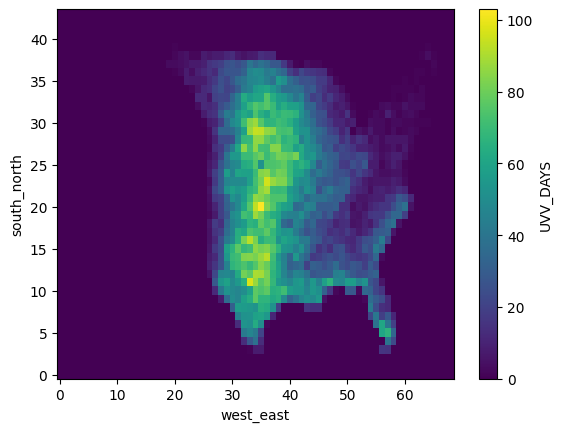

In [13]:
uvv_days_HIST.plot()
plt.show()

In [14]:
print(uvv_HIST)

<xarray.Dataset>
Dimensions:   (Time: 5442, south_north: 44, west_east: 69)
Coordinates:
  * Time      (Time) datetime64[ns] 1990-10-31 1990-11-01 ... 2005-09-23
    lat       (south_north, west_east) float32 dask.array<chunksize=(44, 69), meta=np.ndarray>
    lon       (south_north, west_east) float32 dask.array<chunksize=(44, 69), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east
Data variables:
    CLAT      (Time, south_north, west_east) float32 dask.array<chunksize=(1, 44, 69), meta=np.ndarray>
    CLONG     (Time, south_north, west_east) float32 dask.array<chunksize=(1, 44, 69), meta=np.ndarray>
    UVV_DAYS  (Time, south_north, west_east) int64 dask.array<chunksize=(1, 44, 69), meta=np.ndarray>
Attributes: (12/55)
    BOTTOM-TOP_GRID_DIMENSION:       0
    CEN_LAT:                         38.500003814697266
    CEN_LON:                         -97.5
    DX:                              3750.0
    DY:                              3750.0
    DYN_OPT:         

In [16]:
print(uvv_days_HIST['lon'].values.min(), uvv_days_HIST['lon'].values.max())
print(uvv_days_HIST['lat'].values.min(), uvv_days_HIST['lat'].values.max())

-132.68303 -63.198116
20.884312 52.531593


In [20]:
print("Data shape:", uvv_days_HIST.shape)
print("Lat shape:", uvv_days_HIST['lat'].shape)
print("Lon shape:", uvv_days_HIST['lon'].shape)

Data shape: (44, 69)
Lat shape: (44, 69)
Lon shape: (44, 69)


In [25]:
print("Min value:", np.nanmin(values))
print("Max value:", np.nanmax(values))
print("Lat range:", np.nanmin(lats), np.nanmax(lats))
print("Lon range:", np.nanmin(lons), np.nanmax(lons))


Min value: 0
Max value: 103
Lat range: 20.884312 52.531593
Lon range: -132.68303 -63.198116


In [26]:
print("Center lat/lon value:", lats[22, 34], lons[22, 34])
print("Center data value:", values[22, 34])


Center lat/lon value: 38.515892 -97.90953
Center data value: 70


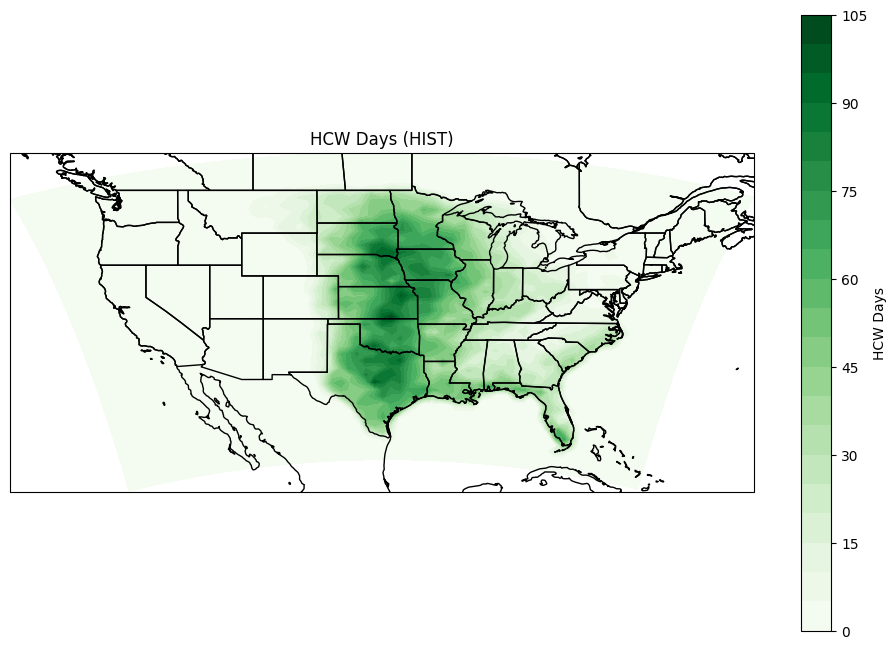

In [28]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
cf = ax.contourf(lons, lats, values, levels=20, cmap='Greens', transform=ccrs.PlateCarree())

plt.colorbar(cf, ax=ax, orientation='vertical', label='HCW Days')
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.COASTLINE)
ax.set_extent([-132.7, -63.2, 20.8, 52.5], crs=ccrs.PlateCarree())
ax.set_title("HCW Days (HIST)")
plt.show()


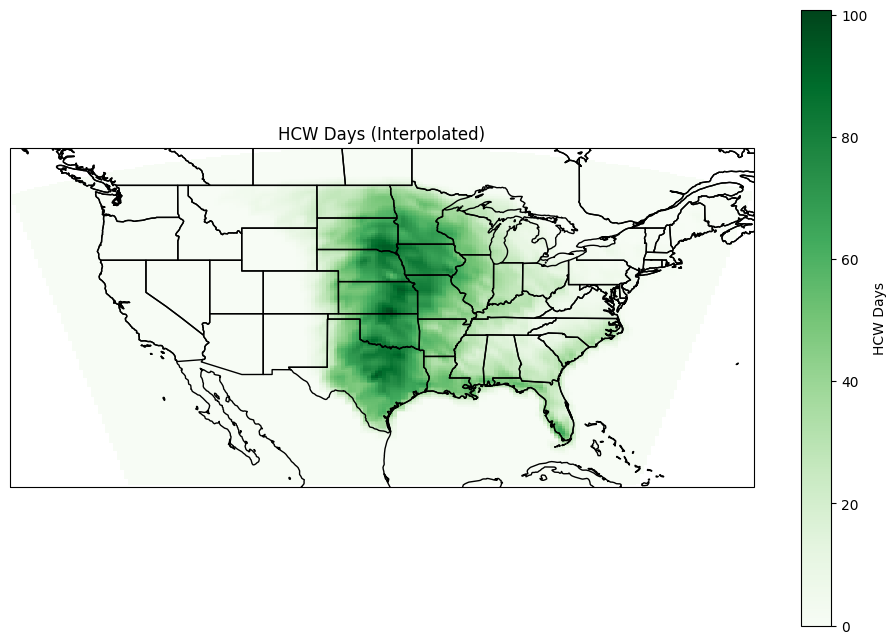

In [29]:
from scipy.interpolate import griddata

# Flatten input
points = np.column_stack((lons.ravel(), lats.ravel()))
values_flat = values.ravel()

# Make new regular grid
lon_new = np.linspace(np.min(lons), np.max(lons), 200)
lat_new = np.linspace(np.min(lats), np.max(lats), 200)
lon_grid, lat_grid = np.meshgrid(lon_new, lat_new)

# Interpolate values to the regular grid
values_interp = griddata(points, values_flat, (lon_grid, lat_grid), method='linear')

# Plot
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
mesh = ax.pcolormesh(lon_grid, lat_grid, values_interp, cmap='Greens', transform=ccrs.PlateCarree(), shading='auto')

plt.colorbar(mesh, ax=ax, orientation='vertical', label='HCW Days')
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.COASTLINE)
ax.set_extent([-132.7, -63.2, 20.8, 52.5], crs=ccrs.PlateCarree())
ax.set_title("HCW Days (Interpolated)")
plt.show()

In [40]:
uvv_days_HIST

<xarray.DataArray 'UVV_DAYS' (south_north: 44, west_east: 69)>
dask.array<sum-aggregate, shape=(44, 69), dtype=int64, chunksize=(44, 69), chunktype=numpy.ndarray>
Coordinates:
    lat      (south_north, west_east) float32 dask.array<chunksize=(44, 69), meta=np.ndarray>
    lon      (south_north, west_east) float32 dask.array<chunksize=(44, 69), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east

In [31]:
# fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
# uvv_days_HIST.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Greens', cbar_kwargs={'label': 'HCW Days'})

# ax.add_feature(cfeature.STATES)
# ax.add_feature(cfeature.COASTLINE)
# ax.set_extent([-132.7, -63.2, 20.8, 52.5], crs=ccrs.PlateCarree())
# ax.set_title('HCW Days (HIST)')
# plt.show()

In [35]:
# # Convert to DataFrame and reset the multi-index to get flat columns
# df = uvv_HIST['UVV_DAYS'].to_dataframe().reset_index()

# # Pull in lat/lon values from the dataset
# lat = uvv_HIST['lat'].values.ravel()
# lon = uvv_HIST['lon'].values.ravel()

In [38]:
# Step 1: Create a meshgrid of the 2D lat/lon values
lat_vals = uvv_HIST['lat'].values
lon_vals = uvv_HIST['lon'].values

# Step 2: Tile lat/lon across time steps
n_time = uvv_HIST.dims['Time']
lat_flat = np.tile(lat_vals.ravel(), n_time)
lon_flat = np.tile(lon_vals.ravel(), n_time)

# Step 3: Repeat time values for each grid cell
time_vals = np.repeat(uvv_HIST['Time'].values, lat_vals.size)

# Step 4: Flatten the data values
uvv_flat = uvv_HIST['UVV_DAYS'].values.reshape(-1)

# Step 5: Create DataFrame
df_HIST = pd.DataFrame({
    'Time': time_vals,
    'Latitude': lat_flat,
    'Longitude': lon_flat,
    'HCW_Days': uvv_flat
})

# Drop missing values
df_HIST = df_HIST.dropna()

In [39]:
# Step 1: Flatten the data as before
ds_HIST = uvv_HIST['UVV_DAYS'].to_dataset(name='HCW_Days')
df_HIST = ds_HIST.to_dataframe().reset_index()

# Step 2: Add seasonal grouping
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    elif month in [9, 10, 11]:
        return 'SON'

df_HIST['Season'] = df_HIST['Time'].dt.month.apply(get_season)
df_HIST['Year'] = df_HIST['Time'].dt.year

# Step 3: Group by Season and Grid Cell
seasonal_df_HIST = df_HIST.groupby(['Year', 'Season', 'lat', 'lon']).agg({'HCW_Days': 'sum'}).reset_index()

In [37]:
# df_HIST.to_csv("/home/scratch/croufa/syn_sev/uvv_days_hist_long.csv", index=False)
seasonal_df_HIST.to_csv("uvv_days_hist_seasonal.csv", index=False)

In [42]:
# zarr method
# Step 1: Open all the NetCDF files as a combined dataset
uvv_8p5END = xr.open_mfdataset(
    '/home/scratch/croufa/syn_sev/8p5END_*.nc',
    combine='by_coords',
    chunks={'time': 100},  # adjust as needed for your memory
    parallel=True
)

# Step 2: Save to Zarr format (faster I/O)
uvv_8p5END.to_zarr('/home/scratch/croufa/syn_sev/uvv_8p5END_combined.zarr', mode='w')

In [43]:
# Step 3: Reopen it quickly later
uvv_8p5END = xr.open_zarr('/home/scratch/croufa/syn_sev/uvv_8p5END_combined.zarr')

In [44]:
# sum number of days with data for each grid point across the time dim
uvv_days_8p5END = uvv_8p5END['UVV_DAYS'].sum(dim='Time')

In [55]:
# export multiple epochs

# === CONFIGURATION ===
# epoch_list = ['HIST', 'MID45', 'MID85', 'END45', 'END85']  # Modify as needed
epoch_list = ['HIST', '8p5END']
input_dir = '/home/scratch/croufa/syn_sev'   # Path where zarr files are stored
output_csv = '/home/scratch/croufa/syn_sev/combined_uvv_days_seasonal.csv'

def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    elif month in [9, 10, 11]:
        return 'SON'

# === PROCESS ALL EPOCHS ===
all_dataframes = []

for epoch in epoch_list:
    print(f'Processing {epoch}...')
    
    # Load dataset
    zarr_path = os.path.join(input_dir, f'uvv_{epoch}_combined.zarr')
    ds = xr.open_zarr(zarr_path, consolidated=False)

    # Extract DataArray
    da = ds['UVV_DAYS']

    # Convert to DataFrame
    df = da.to_dataframe(name='HCW_Days').reset_index()

    # Add time info
    df['Season'] = df['Time'].dt.month.apply(get_season)
    df['Year'] = df['Time'].dt.year
    df['epoch'] = epoch
    df['time_bin'] = df['Year'].astype(str) + '_' + df['Season']

    # Group by season and location
    seasonal_df = df.groupby(['time_bin', 'Year', 'Season', 'lat', 'lon', 'epoch'])['HCW_Days'].sum().reset_index()

    # Append
    all_dataframes.append(seasonal_df)

# === COMBINE AND EXPORT ===
combined_df = pd.concat(all_dataframes, ignore_index=True)
combined_df.to_csv(output_csv, index=False)

print(f"\n✅ Combined CSV exported to: {output_csv}")

Processing HIST...
Processing 8p5END...

✅ Combined CSV exported to: /home/scratch/croufa/syn_sev/combined_uvv_days_seasonal.csv
